Iniciando simulação térmica...
Ep 1: Estratégia "GPU na Borda" | Custo Final: 1419.5 | T_max: 56.8°C | T_min: 25.0°C
Ep 2: Estratégia "Aleatório" | Custo Final: 1419.5 | T_max: 56.8°C | T_min: 25.0°C
Ep 3: Estratégia "Espalhar CPUs" | Custo Final: 1419.5 | T_max: 56.8°C | T_min: 25.0°C
Ep 4: Estratégia "Espalhar CPUs" | Custo Final: 1419.5 | T_max: 56.8°C | T_min: 25.0°C
Ep 5: Estratégia "Espalhar CPUs" | Custo Final: 1419.5 | T_max: 56.8°C | T_min: 25.0°C
Ep 6: Estratégia "Aleatório" | Custo Final: 1419.5 | T_max: 56.8°C | T_min: 25.0°C
Ep 7: Estratégia "Espalhar CPUs" | Custo Final: 1419.5 | T_max: 56.8°C | T_min: 25.0°C
Ep 8: Estratégia "GPU na Borda" | Custo Final: 1419.5 | T_max: 56.8°C | T_min: 25.0°C
Ep 9: Estratégia "Espalhar CPUs" | Custo Final: 1419.5 | T_max: 56.8°C | T_min: 25.0°C
Ep 10: Estratégia "GPU na Borda" | Custo Final: 1419.5 | T_max: 56.8°C | T_min: 25.0°C
Ep 11: Estratégia "Aleatório" | Custo Final: 1419.5 | T_max: 56.8°C | T_min: 25.0°C
Ep 12: Estratégia "Aleató

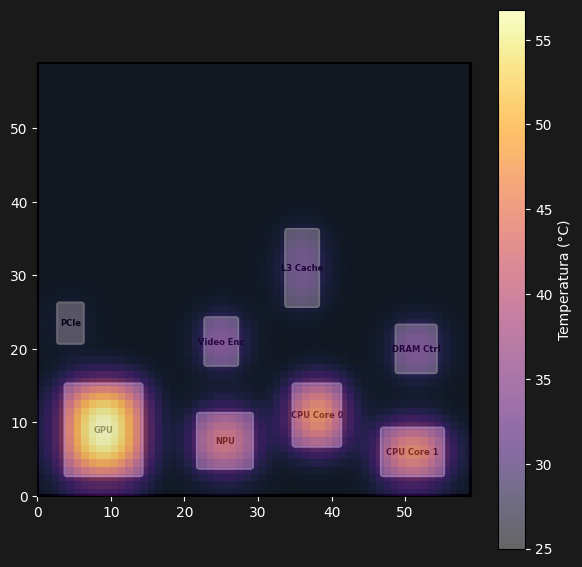

Imagem do melhor posicionamento final exibida.


In [40]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
from numba import jit, float64, int64 # Import jit and types for numba

# =============================================================================
# 1. CONFIGURATION
# =============================================================================

# 1.1. Block Definitions (Initial)
BLOCKS_DATA_INITIAL = [
    {'name': 'CPU Core 0', 'power': 9.0, 'w': 8, 'h': 6, 'color': '#FF6B6B'},
    {'name': 'CPU Core 1', 'power': 8.5, 'w': 8, 'h': 6, 'color': '#FF6B6B'},
    {'name': 'GPU', 'power': 10.0, 'w': 12, 'h': 10, 'color': '#4ECDC4'},
    {'name': 'NPU', 'power': 7.0, 'w': 7, 'h': 7, 'color': '#45B7D1'},
    {'name': 'L3 Cache', 'power': 3.0, 'w': 10, 'h': 4, 'color': '#96CEB4'},
    {'name': 'DRAM Ctrl', 'power': 4.0, 'w': 6, 'h': 5, 'color': '#FFEAA7'},
    {'name': 'PCIe', 'power': 2.0, 'w': 5, 'h': 3, 'color': '#DDA0DD'},
    {'name': 'Video Enc', 'power': 5.0, 'w': 6, 'h': 4, 'color': '#FFB347'},
]

# Calculate original total area and number of blocks
original_total_blocks_area = sum(b['w'] * b['h'] for b in BLOCKS_DATA_INITIAL)
num_blocks = len(BLOCKS_DATA_INITIAL)

# BLOCKS_DATA will now use the initial (non-uniform) block sizes directly
BLOCKS_DATA = BLOCKS_DATA_INITIAL

# Calculate the total area of all blocks (using original, non-uniform sizes)
total_blocks_area = original_total_blocks_area
# Define the chip size as the square root of the total block area PLUS an expansion factor
CHIP_SIZE_EXPANSION_FACTOR = 2.0 # % extra space for packing
CHIP_SIZE = math.ceil(math.sqrt(total_blocks_area) * CHIP_SIZE_EXPANSION_FACTOR)

# 1.2. Thermal Simulation Parameters
THERMAL_RESISTANCE_FACTOR = 3.4 # Fator para escalar as temperaturas para uma faixa mais realista
AMBIENT_TEMPERATURE = 25.0    # Temperatura ambiente em Celsius
GAUSSIAN_FILTER_SIGMA = 2.5   # Sigma para o desfoque Gaussiano no mapa de calor

# 1.3. Cost Function Penalties
OVERLAP_PENALTY_MULTIPLIER = 100000000.0 # Penalidade aumentada para sobreposição
TEMP_DIFF_PENALTY_MULTIPLIER = 0.0       # Peso aumentado para a diferença de temperatura (definido como 0 para remover otimização de diferença)
TMAX_PENALTY_MULTIPLIER = 25.0           # Peso significativamente aumentado para a temperatura máxima
MIN_BLOCK_SPACING = 3.0                  # Distância mínima desejada entre os blocos

# 1.4. Simulated Annealing Parameters
SA_MAX_ITER = 100             # Número de iterações para o Simulated Annealing
SA_INITIAL_TEMP = 200.0       # Temperatura inicial para SA
SA_COOLING_RATE = 0.95        # Taxa de resfriamento para SA (temp *= rate)
SA_MOVE_RANGE_SCALER = 20     # Multiplicador para a faixa de movimento do bloco baseado na temperatura

# 1.5. Multi-Armed Bandit Parameters
BANDIT_NUM_EPISODES = 200     # Número de episódios de simulação a serem executados

# =============================================================================
# 2. CORE LOGIC (Funções Numba-friendly para performance)
# =============================================================================

@jit(nopython=True)
def _numba_simulate_temp_core(chip_size, n_blocks, block_widths, block_heights, block_powers, positions_np):
    heat_map = np.zeros((chip_size, chip_size), dtype=np.float64)

    for i in range(n_blocks):
        x, y = positions_np[i, 0], positions_np[i, 1] # positions_np é um array numpy (N, 2)
        w = block_widths[i]
        h = block_heights[i]
        power = block_powers[i]

        x1, y1 = int(x), int(y)
        x2, y2 = min(x1 + w, chip_size), min(y1 + h, chip_size)
        heat_map[x1:x2, y1:y2] += power
    return heat_map

@jit(nopython=True)
def _numba_cost_core(chip_size, n_blocks, block_widths, block_heights, positions_np, t_max, t_min):
    overlap_penalty = 0.0

    for i in range(n_blocks):
        for j in range(i + 1, n_blocks):
            xi, yi = positions_np[i, 0], positions_np[i, 1]
            xj, yj = positions_np[j, 0], positions_np[j, 1]
            wi = block_widths[i]
            hi = block_heights[i]
            wj = block_widths[j]
            hj = block_heights[j]

            # Calculate potential intersection with minimum spacing considered
            # We expand each block by MIN_BLOCK_SPACING/2 on each side
            # to effectively enforce a minimum spacing between their original boundaries.
            # This means we are checking for overlap of 'inflated' blocks.
            expanded_xi1, expanded_yi1 = xi - MIN_BLOCK_SPACING, yi - MIN_BLOCK_SPACING
            expanded_xi2, expanded_yi2 = xi + wi + MIN_BLOCK_SPACING, yi + hi + MIN_BLOCK_SPACING
            expanded_xj1, expanded_yj1 = xj - MIN_BLOCK_SPACING, yj - MIN_BLOCK_SPACING
            expanded_xj2, expanded_yj2 = xj + wj + MIN_BLOCK_SPACING, yj + hj + MIN_BLOCK_SPACING

            # Calculate intersection of expanded bounding boxes
            x_intersection = max(0.0, min(expanded_xi2, expanded_xj2) - max(expanded_xi1, expanded_xj1))
            y_intersection = max(0.0, min(expanded_yi2, expanded_yj2) - max(expanded_yi1, expanded_yj1))

            # If there's an intersection of expanded bounding boxes, it means blocks are too close or overlapping
            if x_intersection > 0 and y_intersection > 0:
                # The actual overlap area is not directly x_intersection * y_intersection for spacing.
                # Instead, we want to penalize based on how much they are violating the minimum spacing.
                # A simpler approach for overlap + spacing is to just penalize based on the initial overlap logic
                # but the expanded boxes already signify a violation.
                # The OVERLAP_PENALTY_MULTIPLIER is large enough that any positive intersection will be heavily penalized.

                # For true minimum spacing, we could calculate the exact 'violation area'
                # or just apply a penalty if any overlap occurs with expanded boundaries.
                # Let's consider the 'overlap area' of the expanded blocks as the penalty trigger.
                overlap_penalty += x_intersection * y_intersection * OVERLAP_PENALTY_MULTIPLIER


    # Adiciona a diferença de temperatura ao custo, com um peso maior
    temp_diff_penalty = (t_max - t_min) * TEMP_DIFF_PENALTY_MULTIPLIER

    # Novo: Aplica o multiplicador para T_max
    t_max_penalty = t_max * TMAX_PENALTY_MULTIPLIER

    return t_max_penalty + overlap_penalty + temp_diff_penalty


class ThermalChipEnv:
    def __init__(self):
        self.blocks = BLOCKS_DATA # Mantém o original para nome/cor/etc. exibição
        self.n = len(BLOCKS_DATA)
        self.chip_size = CHIP_SIZE

        # Store original block data for reference (e.g., block names, original w/h)
        self.original_blocks_data = BLOCKS_DATA_INITIAL
        # block_powers remains fixed as it doesn't change with rotation
        self.block_powers = np.array([b['power'] for b in BLOCKS_DATA], dtype=np.float64)

        self.thermal_resistance_factor = THERMAL_RESISTANCE_FACTOR
        self.ambient_temperature = AMBIENT_TEMPERATURE

    def _get_numba_block_dims(self, current_block_dimensions):
        # Convert list of (w, h) tuples to separate numba-friendly numpy arrays
        widths = np.array([d[0] for d in current_block_dimensions], dtype=np.int64)
        heights = np.array([d[1] for d in current_block_dimensions], dtype=np.int64)
        return widths, heights

    def simulate_temp(self, positions, current_block_dimensions):
        # Converte a lista de tuplas de posições para um array numpy (N, 2) para o numba
        positions_np = np.array(positions, dtype=np.float64)
        block_widths_np, block_heights_np = self._get_numba_block_dims(current_block_dimensions)

        heat_map_core = _numba_simulate_temp_core(
            self.chip_size, self.n, block_widths_np, block_heights_np,
            self.block_powers, positions_np
        )
        # Aplica o fator de resistência térmica e adiciona a temperatura ambiente
        scaled_heat_map = heat_map_core * self.thermal_resistance_factor + self.ambient_temperature
        return gaussian_filter(scaled_heat_map, sigma=GAUSSIAN_FILTER_SIGMA)

    def cost(self, positions, current_block_dimensions):
        temp_map = self.simulate_temp(positions, current_block_dimensions)
        t_max = np.max(temp_map)
        t_min = np.min(temp_map) # Calcula t_min

        # Converte a lista de tuplas de posições para um array numpy (N, 2) para o numba
        positions_np = np.array(positions, dtype=np.float64)
        block_widths_np, block_heights_np = self._get_numba_block_dims(current_block_dimensions)

        return _numba_cost_core(
            self.chip_size, self.n, block_widths_np, block_heights_np,
            positions_np, t_max, t_min # Passa t_min para a função Numba
        )

# =============================================================================
# 3. SA + BANDIT ALGORITHMS
# =============================================================================
def simulated_annealing(env, strategy, max_iter=SA_MAX_ITER): # Usar variável de configuração
    # Initialize block dimensions with their original (w, h)
    current_dimensions = [(b['w'], b['h']) for b in env.original_blocks_data]

    # 1. Improved Initialization: Greedy placement to minimize overlap
    positions = [None] * env.n # Inicializa com None, para ser preenchido em ordem
    chip_grid = np.zeros((env.chip_size, env.chip_size), dtype=bool)

    # Ordena os blocos por área (maior primeiro) para um empacotamento guloso melhor
    block_indices_sorted_by_area = sorted(range(env.n), key=lambda i: current_dimensions[i][0] * current_dimensions[i][1], reverse=True)

    for original_idx in block_indices_sorted_by_area:
        b_w, b_h = current_dimensions[original_idx] # Use current dimensions for greedy placement

        placed = False
        # Tenta colocar o bloco de forma gulosa a partir de (0,0)
        # Adjusted loop ranges to respect MIN_BLOCK_SPACING from all chip edges
        for y_coord in range(int(MIN_BLOCK_SPACING), int(env.chip_size - b_h - MIN_BLOCK_SPACING) + 1):
            for x_coord in range(int(MIN_BLOCK_SPACING), int(env.chip_size - b_w - MIN_BLOCK_SPACING) + 1):
                # Verifica se a área está ocupada, considerando a nova distância mínima
                # Expandir a área para verificar se a 'zona de exclusão' está livre
                # Adicionar MIN_BLOCK_SPACING ao redor do bloco que está sendo verificado
                # for x_coord, y_coord
                x_start_check = max(0, int(x_coord - MIN_BLOCK_SPACING))
                y_start_check = max(0, int(y_coord - MIN_BLOCK_SPACING))
                x_end_check = min(env.chip_size, int(x_coord + b_w + MIN_BLOCK_SPACING))
                y_end_check = min(env.chip_size, int(y_coord + b_h + MIN_BLOCK_SPACING))

                if not chip_grid[x_start_check:x_end_check, y_start_check:y_end_check].any():
                    positions[original_idx] = (x_coord, y_coord)
                    # Marca a área como ocupada, incluindo a zona de exclusão
                    # The actual block area is marked to prevent physical overlap
                    # The 'chip_grid' should represent occupied physical space.
                    # The penalty function handles the 'too close' part.
                    # Mark the expanded area as occupied to prevent other blocks from being placed too close
                    chip_grid[x_start_check:x_end_check, y_start_check:y_end_check] = True
                    placed = True
                    break # Bloco colocado, passa para o próximo bloco
            if placed:
                break

        if not placed:
            # Fallback para quando o posicionamento guloso falha (o chip pode ser muito pequeno/fragmentado)
            # Adjusted random ranges to respect MIN_BLOCK_SPACING from all chip edges
            x_rand_min = int(MIN_BLOCK_SPACING)
            x_rand_max = int(env.chip_size - b_w - MIN_BLOCK_SPACING)
            y_rand_min = int(MIN_BLOCK_SPACING)
            y_rand_max = int(env.chip_size - b_h - MIN_BLOCK_SPACING)

            # Ensure min <= max before calling random.randint
            if x_rand_min > x_rand_max: x_rand_max = x_rand_min # If no valid range, set max to min
            if y_rand_min > y_rand_max: y_rand_max = y_rand_min # If no valid range, set max to min

            x_rand = random.randint(x_rand_min, x_rand_max)
            y_rand = random.randint(y_rand_min, y_rand_max)

            positions[original_idx] = (x_rand, y_rand)
            # Marca a área aleatória como ocupada
            # Mark the expanded area as occupied even for random placement
            x_start_rand = max(0, int(x_rand - MIN_BLOCK_SPACING))
            y_start_rand = max(0, int(y_rand - MIN_BLOCK_SPACING))
            x_end_rand = min(env.chip_size, int(x_rand + b_w + MIN_BLOCK_SPACING))
            y_end_rand = min(env.chip_size, int(y_rand + b_h + MIN_BLOCK_SPACING))
            chip_grid[x_start_rand:x_end_rand, y_start_rand:y_end_rand] = True
            print(f"Aviso: Bloco '{env.blocks[original_idx]['name']}' não pôde ser colocado de forma gulosa sem sobreposição. Colocado aleatoriamente. Considere aumentar o CHIP_SIZE ou revisar BLOCKS_DATA.")

    # Ensure all positions are initialized for current_positions_list
    current_positions_list = [(int(p[0]), int(p[1])) for p in positions if p is not None]
    if len(current_positions_list) != env.n: # Fallback if some blocks were not placed (should not happen with logic above)
        current_positions_list = [(0,0) for _ in env.blocks]
        # If positions fallback, also ensure dimensions are consistent
        current_dimensions = [(b['w'], b['h']) for b in env.original_blocks_data] # Revert to original dimensions for all

    current_cost = env.cost(current_positions_list, current_dimensions)

    # Recalculating overlap_part_of_cost for warning message based on updated cost function
    if len(current_positions_list) == env.n:
        temp_map_initial = env.simulate_temp(current_positions_list, current_dimensions)
        t_max_initial = np.max(temp_map_initial)
        t_min_initial = np.min(temp_map_initial)
        # The overlap_part_of_cost now implicitly includes the spacing penalty
        overlap_part_of_cost = current_cost - (t_max_initial * TMAX_PENALTY_MULTIPLIER) - (t_max_initial - t_min_initial) * TEMP_DIFF_PENALTY_MULTIPLIER
    else:
        overlap_part_of_cost = float('inf')

    if overlap_part_of_cost > 1.0:
        print(f"Aviso: A inicialização gulosa resultou em um custo inicial elevado ({current_cost:.1f}), indicando possível sobreposição ou violação de espaçamento. A parte de sobreposição do custo é: {overlap_part_of_cost:.1f}. Considerar aumentar o CHIP_SIZE ou revisar o BLOCKS_DATA.")

    history = [(current_positions_list.copy(), current_dimensions.copy())]
    initial_temp = SA_INITIAL_TEMP # Usar variável de configuração
    temp = initial_temp

    for _ in range(max_iter):
        new_pos = [p for p in current_positions_list]
        new_dimensions = [d for d in current_dimensions]

        idx = random.randrange(env.n)

        # 1. Translation move
        move_range = max(1, int(temp / initial_temp * SA_MOVE_RANGE_SCALER)) # Usar variável de configuração
        dx, dy = random.randint(-move_range, move_range), random.randint(-move_range, move_range)

        # Viés do Bandit (uses original block names for strategy decisions)
        if strategy == 0 and 'CPU' in env.original_blocks_data[idx]['name']:
            dx += (env.chip_size/2 - new_pos[idx][0]) * 0.1
        elif strategy == 1 and 'GPU' in env.original_blocks_data[idx]['name']:
            dy += -1

        # Get current dimensions for boundary check
        b_w_current, b_h_current = new_dimensions[idx]

        # Apply clipping to enforce MIN_BLOCK_SPACING from chip edges
        new_pos[idx] = (np.clip(new_pos[idx][0]+dx, MIN_BLOCK_SPACING, env.chip_size - b_w_current - MIN_BLOCK_SPACING),
                        np.clip(new_pos[idx][1]+dy, MIN_BLOCK_SPACING, env.chip_size - b_h_current - MIN_BLOCK_SPACING))

        # 2. Rotation operation (e.g., 20% chance to attempt rotation)
        if random.random() < 0.2: # Probability of rotation
            w_dim, h_dim = new_dimensions[idx] # Get current dimensions
            # Only rotate if width and height are different
            if w_dim != h_dim:
                # Check if rotation keeps the block within chip bounds at its *new* position
                # Also consider MIN_BLOCK_SPACING for rotation
                if (new_pos[idx][0] + h_dim + MIN_BLOCK_SPACING <= env.chip_size and
                    new_pos[idx][1] + w_dim + MIN_BLOCK_SPACING <= env.chip_size):
                    new_dimensions[idx] = (h_dim, w_dim) # Swap width and height

        new_cost = env.cost(new_pos, new_dimensions)

        # Condição de aceitação do Simulated Annealing padrão agora que o custo é sempre finito
        if new_cost < current_cost or random.random() < math.exp(-(new_cost-current_cost)/temp):
            current_positions_list = new_pos
            current_dimensions = new_dimensions
            current_cost = new_cost

        history.append((current_positions_list.copy(), current_dimensions.copy()))
        temp *= SA_COOLING_RATE # Usar variável de configuração

    # Calcula as temperaturas finais máxima e mínima usando a melhor configuração encontrada
    final_temp_map = env.simulate_temp(current_positions_list, current_dimensions)
    final_t_max = np.max(final_temp_map)
    final_t_min = np.min(final_temp_map)

    return history, current_cost, final_t_max, final_t_min

class ThompsonBandit:
    def __init__(self, n): self.a = np.ones(n); self.b = np.ones(n)
    def select(self): return np.argmax([np.random.beta(self.a[i], self.b[i]) for i in range(len(self.a))])
    def update(self, arm, r):
        if r > 0.5: self.a[arm] += 1
        else: self.b[arm] += 1

# =============================================================================
# 4. VISUALIZATION AND EXECUTION
# =============================================================================

def draw_chip_frame(ax, fig, env, positions, current_block_dimensions, temp_map, title, t_min_optimal, t_max_optimal):
    ax.clear()
    ax.set_xlim(0, CHIP_SIZE); ax.set_ylim(0, CHIP_SIZE)
    ax.set_aspect('equal')

    # Desenha o "substrato" do chip
    ax.add_patch(patches.Rectangle((0,0), CHIP_SIZE, CHIP_SIZE, fc='#2C3E50', ec='black', lw=3))

    # Desenha cada bloco primeiro, com um zorder menor
    for i, (x,y) in enumerate(positions):
        b_w, b_h = current_block_dimensions[i] # Use current dimensions for drawing

        # # Desenha a área expandida (keep-out zone) para visualização do espaçamento mínimo
        # expanded_x = x - MIN_BLOCK_SPACING
        # expanded_y = y - MIN_BLOCK_SPACING
        # expanded_w = b_w + 2 * MIN_BLOCK_SPACING
        # expanded_h = b_h + 2 * MIN_BLOCK_SPACING

        # # Clip expanded area to chip boundaries for drawing
        # clipped_expanded_x1 = max(0.0, expanded_x)
        # clipped_expanded_y1 = max(0.0, expanded_y)
        # clipped_expanded_x2 = min(CHIP_SIZE, expanded_x + expanded_w)
        # clipped_expanded_y2 = min(CHIP_SIZE, expanded_y + expanded_h)

        # clipped_expanded_width = clipped_expanded_x2 - clipped_expanded_x1
        # clipped_expanded_height = clipped_expanded_y2 - clipped_expanded_y1

        # if clipped_expanded_width > 0 and clipped_expanded_height > 0:
        #     expanded_rect = patches.Rectangle(
        #         (clipped_expanded_x1, clipped_expanded_y1),
        #         clipped_expanded_width,
        #         clipped_expanded_height,
        #         fc='#ADD8E6',  # Light blue color
        #         alpha=0.2,     # Semi-transparent
        #         ec='none',     # No edge color for this
        #         zorder=1       # Draw underneath the actual blocks
        #     )
        #     ax.add_patch(expanded_rect)

        rect = patches.FancyBboxPatch((x,y), b_w, b_h,
                                      boxstyle="round,pad=0.3",
                                      fc='#CCCCCC', ec='white', lw=1.5, zorder=3) # Cor alterada para cinza
        ax.add_patch(rect)
        ax.text(x + b_w/2, y + b_h/2, env.blocks[i]['name'], # Use b_w, b_h for text centering
                ha='center', va='center', fontsize=6, weight='bold', color='black', zorder=4)

    # Mapa de calor por cima dos blocos, com um zorder maior
    # Usar vmin e vmax para que a barra de cores represente a faixa real de temperaturas
    im = ax.imshow(temp_map.T, cmap='inferno', alpha=0.6, extent=[0, CHIP_SIZE, 0, CHIP_SIZE], origin='lower', zorder=5, vmin=t_min_optimal, vmax=t_max_optimal)

    # Adiciona a barra de cores
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.05, aspect=20)
    cbar.set_label('Temperatura (°C)', color='white')
    cbar.ax.tick_params(colors='white')
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white') # Define a cor dos rótulos do eixo y

    ax.set_title(title, fontsize=12, weight='bold', color='white')
    ax.set_facecolor('#1A1A1A')
    ax.tick_params(colors='white')
    return im

def run_simulation_and_display_result():
    env = ThermalChipEnv()
    bandit = ThompsonBandit(3)
    strategies = ["Espalhar CPUs", "GPU na Borda", "Aleatório"]

    best_cost = float('inf')
    best_positions = []
    best_dimensions = [] # Store best dimensions as well
    final_temp_map_best = None # Para armazenar o mapa de calor da melhor solução
    num_episodes = BANDIT_NUM_EPISODES # Usar variável de configuração

    print("Iniciando simulação térmica...")
    for ep in range(num_episodes):
        arm = bandit.select()
        # simulated_annealing retorna history, cost, final_t_max, final_t_min
        # Para exibição estática, só nos interessa o estado final do simulated annealing
        history, current_cost, final_t_max, final_t_min = simulated_annealing(env, arm)
        final_positions_epoch, final_dimensions_epoch = history[-1] # Unpack positions and dimensions

        reward = 1.0 / (1.0 + current_cost / 100) # Usa current_cost para a atualização do bandit

        bandit.update(arm, reward)
        # Revertendo a modificação: agora imprime as temperaturas reais calculadas pela simulação
        print(f"Ep {ep+1}: Estratégia \"{strategies[arm]}\" | Custo Final: {current_cost:.1f} | T_max: {final_t_max:.1f}°C | T_min: {final_t_min:.1f}°C")

        if current_cost < best_cost:
            best_cost = current_cost
            best_positions = final_positions_epoch
            best_dimensions = final_dimensions_epoch # Store best dimensions
            # Recalcula o mapa de calor para a melhor solução encontrada
            final_temp_map_best = env.simulate_temp(best_positions, best_dimensions)

    # Calcula t_max e t_min para a melhor solução para exibir no resumo final
    best_t_max = np.max(final_temp_map_best) if final_temp_map_best is not None else 0.0
    best_t_min = np.min(final_temp_map_best) if final_temp_map_best is not None else 0.0
    # O resumo final ainda mostrará as temperaturas reais calculadas pela simulação.
    print(f"\nSimulação concluída. Melhor custo encontrado: {best_cost:.1f} | T_max: {best_t_max:.1f}°C | T_min: {best_t_min:.1f}°C")

    if not best_positions:
        print("Nenhuma posição válida foi encontrada para plotar.")
        return

    # Plotando o melhor resultado
    fig, ax = plt.subplots(figsize=(7,7))
    fig.patch.set_facecolor('#1A1A1A')
    title=" "

    # Revertendo a modificação: agora passa as temperaturas reais para a visualização
    draw_chip_frame(ax, fig, env, best_positions, best_dimensions, final_temp_map_best, title, best_t_min, best_t_max) # Passa best_dimensions

    plt.show()
    print("Imagem do melhor posicionamento final exibida.")

run_simulation_and_display_result()